# Proyecto dataset de Titanic

Este proyecto tiene por objetivo analizar datos sobre los registros de sobrevivientes del titanic. Utilizando como base de información los archivos que se encuentran en https://www.kaggle.com/competitions/titanic/data. El fin es poder predecir mediante sus datos cuales son las personas que sobreviven o no. Además de identificar cuales son los factores que mas influyen en las probabilidades de sobrevivir.

Algunas explicaciones de columnas:  
- Pclass = Clase del ticket: 1st, 2nd, 3rd
- SibSp = Número de hermanos o cónyugues arriba del titanic
- Parch = Número de familiares o hijos arriba del titanic
- Ticket = Número del ticket
- Fare = Tarifa
- Cabin = Número de la cabina
- Embarked = Puerto de embarcación: C(Cherbourg), Q(Queenstown), S(Southampton)

### Imports necesarios

In [51]:
import pandas as pd
import random
import plotly.express as px
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Carga de datos

In [52]:
ruta_train_csv = r'../data/raw/train.csv'
df_inicial_train = pd.read_csv(ruta_train_csv)

### Visualización inicial

DataFrame cargado inicial:

In [53]:
print(f'Datos iniciales:\n{df_inicial_train}')

Datos iniciales:
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 .

Info del DataFrame y describe

In [54]:
df_inicial_train.info()
print(f'\nDescribe:\n{df_inicial_train.describe()}')

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Describe:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.83

### EDA

Rellenar valores de Age con la mediana

In [55]:
info_rellenar_datos_age = {'Age': df_inicial_train['Age'].median()}
df_edad_rellenada = df_inicial_train.fillna(info_rellenar_datos_age)
print(f'DataFrame con Age completo:\n{df_edad_rellenada}')
df_edad_rellenada.info()

DataFrame con Age completo:
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                       

Quitar la columna Cabin, para este ejercicio no se considerará debido a su cantidad de valores distintos, no se podría clasificar

In [56]:
df_drop_cabin = df_edad_rellenada.drop(columns=['Cabin'])

Rellenar los valores faltantes de Embarked, son pocos pero esto es para tener un DataFrame mas limpio y fácil de trabajar. Se aplica la funcion lambda en donde es "na" se elige un Embarked aleatorio

In [57]:
moda_embarked = df_drop_cabin['Embarked'].mode().iloc[0]
print(str(moda_embarked))
df_drop_cabin['Embarked'] = df_drop_cabin['Embarked'].fillna(moda_embarked)
df_drop_cabin.info()
df_procesado = df_drop_cabin
df_procesado.info()

S
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int

### Creación de gráficos para entendimiento

Crear columna de sobrevivientes en palabras, esto para crear un gráfico mas entendible y amigable

In [58]:
df_procesado['Sobreviviente'] = df_procesado['Survived'].map({0: 'No sobrevivió', 1: 'Sobrevivió'})
print(f'DataFrame con columna de sobreviviente o no:\n{df_procesado}')

DataFrame con columna de sobreviviente o no:
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                      

1. Generar DataFrame solo de mujeres, para contar cuantos sobrevivientes y no sobrevivientes hay. Luego mapear colores para que en el gráfico se vean colores especificos dependiendo si es sobreviviente o no.

In [59]:
df_mujeres = df_procesado[df_procesado['Sex'] == 'female']
cuenta_sobrevivientes_mujeres = df_mujeres['Sobreviviente'].value_counts()
cuenta_sobrevivientes_mujeres = cuenta_sobrevivientes_mujeres.reset_index()
print(cuenta_sobrevivientes_mujeres)
mapeo_colores = {
    'Sobrevivió': '#4365ff',
    'No sobrevivió': '#ff4848'
}



   Sobreviviente  count
0     Sobrevivió    233
1  No sobrevivió     81


1.1 Gráfico de sobrevivientes mujeres

In [60]:
fig_pie_sobrevivientes_female = px.pie(
    cuenta_sobrevivientes_mujeres,
    values='count',
    names='Sobreviviente',
    color='Sobreviviente',
    color_discrete_map=mapeo_colores
)

fig_pie_sobrevivientes_female.show()

2. Realizar misma accion para los hombres

In [61]:
df_hombres = df_procesado[df_procesado['Sex'] == 'male']
cuenta_sobrevivientes_hombres = df_hombres['Sobreviviente'].value_counts()
cuenta_sobrevivientes_hombres = cuenta_sobrevivientes_hombres.reset_index()
print(cuenta_sobrevivientes_hombres)
mapeo_colores = {
    'Sobrevivió': '#4365ff',
    'No sobrevivió': '#ff4848'
}


   Sobreviviente  count
0  No sobrevivió    468
1     Sobrevivió    109


2.2 Gráfico de sobrevivientes hombres

In [62]:
fig_pie_sobrevivientes_hombres = px.pie(
    cuenta_sobrevivientes_hombres,
    values='count',
    names='Sobreviviente',
    color='Sobreviviente',
    color_discrete_map=mapeo_colores
)

fig_pie_sobrevivientes_hombres.show()

3. Ahora buscar taza de sobrevivientes por rangos de edad, primero utilizar una cantidad considerable (mayor a 100) registros por cada grupo para identificar si hay alguna tendencia y que sea fidedigna

In [63]:
df_jovenes_debajo_18 = df_procesado[df_procesado['Age'] <= 18]
df_adultos_18_40 = df_procesado[(df_procesado['Age'] > 18) & (df_procesado['Age'] <= 40)]
df_adultos_sobre_40 = df_procesado[df_procesado['Age'] > 40]
print(len(df_jovenes_debajo_18))
print(len(df_adultos_18_40))
print(len(df_adultos_sobre_40))

139
602
150


3.1 Crear y manejar datos para ver sobrevivientes jovenes

In [64]:
sobrevivientes_debajo_18 = df_jovenes_debajo_18['Sobreviviente'].value_counts()
sobrevivientes_debajo_18 = sobrevivientes_debajo_18.reset_index()
print(sobrevivientes_debajo_18)

mapeo_colores = {
    'Sobrevivió': '#4365ff',
    'No sobrevivió': '#ff4848'
}


   Sobreviviente  count
0     Sobrevivió     70
1  No sobrevivió     69


3.2 Gráfico de sobrevivientes "jovenes"

In [65]:
fig_pie_sobrevivientes_jovenes = px.pie(
    sobrevivientes_debajo_18,
    values='count',
    names='Sobreviviente',
    color='Sobreviviente',
    color_discrete_map=mapeo_colores
)
fig_pie_sobrevivientes_jovenes.show()

3.3 Realizar lo mismo para los pasajeros con edad entre 18 y 40 años

In [66]:
sobrevivientes_18_40 = df_adultos_18_40['Sobreviviente'].value_counts()
sobrevivientes_18_40 = sobrevivientes_18_40.reset_index()
print(sobrevivientes_18_40)

mapeo_colores = {
    'Sobrevivió': '#4365ff',
    'No sobrevivió': '#ff4848'
}


   Sobreviviente  count
0  No sobrevivió    385
1     Sobrevivió    217


3.4 Gráfico sobrevivientes entre 18 y 40 años

In [67]:
fig_pie_sobrevivientes_18_40 = px.pie(
    sobrevivientes_18_40,
    values='count',
    names='Sobreviviente',
    color='Sobreviviente',
    color_discrete_map=mapeo_colores
)

fig_pie_sobrevivientes_18_40.show()

3.5 Realizar lo mismo para pasajeros mayores a 40 años

In [68]:
sobrevivientes_mayores_40 = df_adultos_sobre_40['Sobreviviente'].value_counts()
sobrevivientes_mayores_40 = sobrevivientes_mayores_40.reset_index()
print(sobrevivientes_mayores_40)

mapeo_colores = {
    'Sobrevivió': '#4365ff',
    'No sobrevivió': '#ff4848'
}



   Sobreviviente  count
0  No sobrevivió     95
1     Sobrevivió     55


3.6 Gráfico para sobrevivientes mayores a 40 años

In [69]:
fig_pie_sobrevivientes_mayores_40 = px.pie(
    sobrevivientes_mayores_40,
    values='count',
    names='Sobreviviente',
    color='Sobreviviente',
    color_discrete_map=mapeo_colores
)

fig_pie_sobrevivientes_mayores_40.show()

4. Para este apartado analizar si el precio de la tarifa (Fare) puede tener que ver con la sobrevivencia, pero antes saber que se puede conocer como Fare alto o bajo, para ello realizar un histograma

In [70]:
fig_histograma_fares = px.histogram(
    df_procesado,
    x='Fare'
)
fig_histograma_fares.show()

4.1 Ahora conociendo los datos de que casi todos los pasajeros tenian un fare de 15 o menor, se separa por ese número

In [71]:
df_fare_bajo = df_procesado[df_procesado['Fare'] <= 15]
cuenta_sobrevivientes_fare_bajo = df_fare_bajo['Sobreviviente'].value_counts()
cuenta_sobrevivientes_fare_bajo = cuenta_sobrevivientes_fare_bajo.reset_index()
print(cuenta_sobrevivientes_fare_bajo)

mapeo_colores = {
    'Sobrevivió': '#4365ff',
    'No sobrevivió': '#ff4848'
}



   Sobreviviente  count
0  No sobrevivió    344
1     Sobrevivió    114


4.2 Gráfico para sobrevivientes de "Fare" bajo

In [72]:
fig_sobrevivientes_fare_bajo = px.pie(
    cuenta_sobrevivientes_fare_bajo,
    values='count',
    names='Sobreviviente',
    color='Sobreviviente',
    color_discrete_map=mapeo_colores
)

fig_sobrevivientes_fare_bajo.show()

4.3 Crear DataFrame con registros con "Fare" mas alto

In [73]:
df_fare_alto = df_procesado[df_procesado['Fare'] > 15]
cuenta_sobrevivientes_fare_alto = df_fare_alto['Sobreviviente'].value_counts()
cuenta_sobrevivientes_fare_alto = cuenta_sobrevivientes_fare_alto.reset_index()
print(cuenta_sobrevivientes_fare_alto)

mapeo_colores = {
    'Sobrevivió': '#4365ff',
    'No sobrevivió': '#ff4848'
}


   Sobreviviente  count
0     Sobrevivió    228
1  No sobrevivió    205


4.4 Gráfico para pasajeros con "Fare" mas alto

In [74]:
fig_sobrevivientes_fare_alto = px.pie(
    cuenta_sobrevivientes_fare_alto,
    values='count',
    names='Sobreviviente',
    color='Sobreviviente',
    color_discrete_map=mapeo_colores
)

fig_sobrevivientes_fare_alto.show()

5. Generar DataFrame con la información necesaria para ver si la "Pclass" tiene que ver con la sobrevivencia

5.1 Primero obtener datos de "Pclass" = 1

In [75]:
df_pclass_1 = df_procesado[df_procesado['Pclass'] == 1]
sobrevivientes_pclass_1 = df_pclass_1['Sobreviviente'].value_counts()
sobrevivientes_pclass_1 = sobrevivientes_pclass_1.reset_index()
print(sobrevivientes_pclass_1)

mapeo_colores = {
    'Sobrevivió': '#4365ff',
    'No sobrevivió': '#ff4848'
}

   Sobreviviente  count
0     Sobrevivió    136
1  No sobrevivió     80


5.2 Gráfico de sobrevivientes en Pclass = 1

In [76]:
fig_pie_sobrevivientes_pclass_1 = px.pie(
    sobrevivientes_pclass_1,
    values='count',
    names='Sobreviviente',
    color='Sobreviviente',
    color_discrete_map=mapeo_colores
)

fig_pie_sobrevivientes_pclass_1.show()

5.3 Datos para Pclass = 2

In [77]:
df_pclass_2 = df_procesado[df_procesado['Pclass'] == 2]
sobrevivientes_pclass_2 = df_pclass_2['Sobreviviente'].value_counts()
sobrevivientes_pclass_2 = sobrevivientes_pclass_2.reset_index()
print(sobrevivientes_pclass_2)

mapeo_colores = {
    'Sobrevivió': '#4365ff',
    'No sobrevivió': '#ff4848'
}

   Sobreviviente  count
0  No sobrevivió     97
1     Sobrevivió     87


5.4 Gráfico sobrevivientes en Pclass = 2

In [78]:
fig_pie_sobrevivientes_pclass_2 = px.pie(
    sobrevivientes_pclass_2,
    values='count',
    names='Sobreviviente',
    color='Sobreviviente',
    color_discrete_map=mapeo_colores
)

fig_pie_sobrevivientes_pclass_2.show()

5.5 Datos para Pclass = 3

In [79]:
df_pclass_3 = df_procesado[df_procesado['Pclass'] == 3]
sobrevivientes_pclass_3 = df_pclass_3['Sobreviviente'].value_counts()
sobrevivientes_pclass_3 = sobrevivientes_pclass_3.reset_index()
print(sobrevivientes_pclass_3)

mapeo_colores = {
    'Sobrevivió': '#4365ff',
    'No sobrevivió': '#ff4848'
}

   Sobreviviente  count
0  No sobrevivió    372
1     Sobrevivió    119


5.6 Gráfico sobrevivientes en Pclass = 3

In [80]:
fig_pie_sobrevivientes_pclass_3 = px.pie(
    sobrevivientes_pclass_3,
    values='count',
    names='Sobreviviente',
    color='Sobreviviente',
    color_discrete_map=mapeo_colores
)

fig_pie_sobrevivientes_pclass_3.show()

6. Obtener información para saber si el lugar donde fue embarcado tiene relación

6.1 Info de Embarked = C

In [81]:
df_embarked_c = df_procesado[df_procesado['Embarked'] == 'C']
sobrevivientes_embarked_c = df_embarked_c['Sobreviviente'].value_counts()
sobrevivientes_embarked_c = sobrevivientes_embarked_c.reset_index()
print(sobrevivientes_embarked_c)

mapeo_colores = {
    'Sobrevivió': '#4365ff',
    'No sobrevivió': '#ff4848'
}

   Sobreviviente  count
0     Sobrevivió     93
1  No sobrevivió     75


6.2 Gráfico sobrevivientes Embarked = C

In [82]:
fig_pie_sobrevivientes_embarked_c = px.pie(
    sobrevivientes_embarked_c,
    values='count',
    names='Sobreviviente',
    color='Sobreviviente',
    color_discrete_map=mapeo_colores
)

fig_pie_sobrevivientes_embarked_c.show()

6.4 Info Embarked = Q

In [83]:
df_embarked_q = df_procesado[df_procesado['Embarked'] == 'Q']
sobrevivientes_embarked_q = df_embarked_q['Sobreviviente'].value_counts()
sobrevivientes_embarked_q = sobrevivientes_embarked_q.reset_index()
print(sobrevivientes_embarked_q)

mapeo_colores = {
    'Sobrevivió': '#4365ff',
    'No sobrevivió': '#ff4848'
}

   Sobreviviente  count
0  No sobrevivió     47
1     Sobrevivió     30


6.5 Gráfico sobrevivientes Embarked = Q

In [84]:
fig_pie_sobrevivientes_embarked_q = px.pie(
    sobrevivientes_embarked_q,
    values='count',
    names='Sobreviviente',
    color='Sobreviviente',
    color_discrete_map=mapeo_colores
)

fig_pie_sobrevivientes_embarked_q.show()

6.6 Info Embarked = S

In [85]:
df_embarked_s = df_procesado[df_procesado['Embarked'] == 'S']
sobrevivientes_embarked_s = df_embarked_s['Sobreviviente'].value_counts()
sobrevivientes_embarked_s = sobrevivientes_embarked_s.reset_index()
print(sobrevivientes_embarked_s)

mapeo_colores = {
    'Sobrevivió': '#4365ff',
    'No sobrevivió': '#ff4848'
}

   Sobreviviente  count
0  No sobrevivió    427
1     Sobrevivió    219


6.7 Gráfico sobrevivientes Embarked = S

In [86]:
fig_pie_sobrevivientes_embarked_s = px.pie(
    sobrevivientes_embarked_s,
    values='count',
    names='Sobreviviente',
    color='Sobreviviente',
    color_discrete_map=mapeo_colores
)

fig_pie_sobrevivientes_embarked_s.show()

### Machine Learning

Para el trabajo con machine learning la idea es poder aprender con los datos que tenemos y después poder predecir información

1. Primero quitaremos columnas que no vamos a utilizar, cambiar los valores de Sex a 0 y 1. Además lógica para crear 3 columnas, una para cada tipo de Embarked, marcando 1 en donde corresponda.

In [87]:
df_ml = df_procesado.drop(columns=['PassengerId', 'Name', 'Ticket', 'Sobreviviente'])

df_ml['Sex'] = df_ml['Sex'].map({'female': 0, 'male': 1})

df_ml['Embarked_C'] = (df_ml['Embarked'] == 'C').astype(int)
df_ml['Embarked_Q'] = (df_ml['Embarked'] == 'Q').astype(int)
df_ml['Embarked_S'] = (df_ml['Embarked'] == 'S').astype(int)

df_ml = df_ml.drop(columns=['Embarked'])

2. Separar los datos para entrenamiento y pruebas. Stratify con "y" para que la cantidad de "Survived" se separe de manera parecia y no tengamos un entrenamiento con demasiados registros de sobrevivientes o demasiados no sobrevivientes (que sea parejo)    
Ademas quitamos una columna de Embarked para evitar dummy's, ya que es obvio que si Embarked_C=0 y Embarked_S=0 por lógica el Embarked_Q seria 1, no tiene sentido colocar otra columna señalandolo, ya que las 3 columnas dependen entre sí.

In [88]:
X = df_ml.drop(columns=['Survived', 'Embarked_Q'])
y = df_ml['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=7, stratify=y)




3. Escalar datos necesarios, recordar que en los modelos de ML datos que son demasiado diferentes entre si provocan que al modelo le cueste mas converger. Esto se hace despues de separar train y test para que el escalador haga fit(aprenda) a escalar con los datos de entrenamiento y luego solo transforme los datos del test utilizando la forma aprendida.  
Además se ocupa 1 objeto escalador que guarda la forma de escalar de "Age" y "Fare" en ese orden, entonces cuando se transforma es necesario escalar en el mismo orden ya que va a aplicar lo aprendido en el orden de "Age" y "Fare" respectivamente

In [89]:
scaler_standardscaler = StandardScaler()
X_train[['Age', 'Fare','SibSp', 'Parch']] = scaler_standardscaler.fit_transform(X_train[['Age', 'Fare', 'SibSp', 'Parch']])
X_test[['Age', 'Fare', 'SibSp', 'Parch']] = scaler_standardscaler.transform(X_test[['Age', 'Fare', 'SibSp', 'Parch']])

4. Calcular el tamaño de la familia del pasajero, tal vez tenga que ver con su sobreviviencia

4. Crear y entrenar modelo

In [90]:
model = LogisticRegression(
    max_iter=2000, # Iteraciones altas, lo que pasa es que con bajas no llega a una generalización por multiples factores posibles
    random_state=7
)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",7
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

5. Medir modelo

In [91]:
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.8117977528089888
0.7597765363128491


6. Realizar predicciones

In [92]:
y_pred = model.predict(X_test)

7. Obtener métricas a raíz de las predicciones

[[89 21]
 [22 47]]


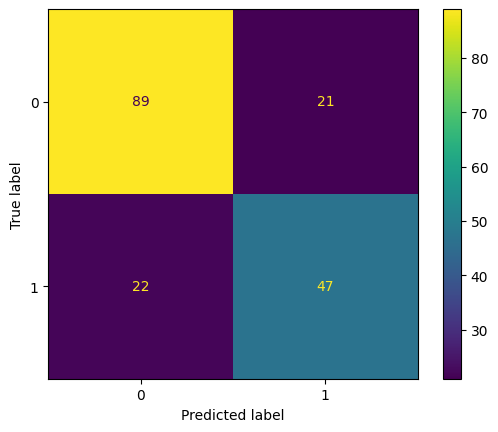

In [93]:
matriz_confusion = confusion_matrix(y_test, y_pred)
print(matriz_confusion)
display_matriz_confusion = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion)
print(display_matriz_confusion)
display_matriz_confusion.plot()